Supervised Nueral Networks for Classification

In [14]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, precision_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic_train_minmax_scaled.csv")

df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.271174,0.125,0.000000,0.014151,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.472229,0.125,0.000000,0.139136,1.0,0.0,1.0,0.0,0.0
2,1.0,1.0,0.321438,0.000,0.000000,0.015469,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.434531,0.125,0.000000,0.103644,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.434531,0.000,0.000000,0.015713,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,0.5,0.334004,0.000,0.000000,0.025374,0.0,1.0,0.0,0.0,1.0
887,1.0,0.0,0.233476,0.000,0.000000,0.058556,1.0,0.0,0.0,0.0,1.0
888,0.0,1.0,0.367921,0.125,0.333333,0.045771,1.0,0.0,0.0,0.0,1.0
889,1.0,0.0,0.321438,0.000,0.000000,0.058556,0.0,1.0,1.0,0.0,0.0


In [29]:
class TitanicDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.x = torch.tensor(df.drop(columns = ['Survived']).values, dtype = torch.float32)
        # self.y = torch.tensor(df['Survived'].values, dtype = torch.float32)
        self.labels = torch.tensor(df["Survived"].values, dtype=torch.long)
        self.y = torch.zeros((len(self.labels), 2), dtype=torch.float32)
        self.y[torch.arange(len(self.labels)), self.labels] = 1.0

    def __len__(self):
        self.len = len(self.df)
        return self.len
    
    def __getitem__(self, index):
        return (self.x[index], self.y[index])
    
dataset = TitanicDataset(df)
n_total = len(dataset)
n_train = int(0.8 * n_total)
#n_val = 0.1 * n_total
n_test = int(n_total - n_train)

train_ds, test_ds = random_split(dataset, [n_train, n_test]) #similar to train-test-split from sklearn
train_loader = DataLoader(train_ds, batch_size = 5, shuffle = False)
test_loader = DataLoader(test_ds, batch_size = 5, shuffle = False)

In [30]:
class TitanicNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_to_hidden1 = nn.Linear(10, 64)
        self.hidden1_to_hidden2 = nn.Linear(64, 32)
        self.hidden2_to_output = nn.Linear(32, 2)
        self.relu = nn.ReLU() # a transformation for values

    # Shape (B, n)
    def forward(self, x):
        x = self.input_to_hidden1(x) # same as using .forward(x)
        x = self.relu(x)
        x = self.hidden1_to_hidden2(x)
        x = self.relu(x)
        x = self.hidden2_to_output(x)

        return x

class TitanicNeuralNetworkResidual(nn.Module):
    def __init__(self):
        super().__init__()

        self.input_to_hidden1 = nn.Linear(10, 64)
        self.residual_projection = nn.Linear(64, 32)
        self.hidden1_to_hidden2 = nn.Linear(64, 32)
        self.hidden2_to_output = nn.Linear(32, 2)
        self.relu = nn.ReLU() # a transformation for values

    # Shape (B, n)
    def forward(self, x):
        x = self.input_to_hidden1(x) # same as using .forward(x)
        x = self.relu(x)
        residuals = self.residual_projection(x)
        x = self.hidden1_to_hidden2(x)
        x = self.relu(x)
        x = x + residuals # creates the skip connection
        x = self.hidden2_to_output(x)

        return x

In [31]:
def train_fn(model, loader, optimizer, loss_fn):
    model.train()

    ave_loss = 0.0
    counter = 0

    for batch_idx, (x, y) in enumerate(loader):
        predictions = model.forward(x)

        loss = loss_fn(predictions, y)

        optimizer.zero_grad()
        loss.backward() #backward propagation
        optimizer.step()

        counter += 1
        ave_loss += loss.item()

    ave_loss = ave_loss / counter

    return ave_loss

# A lower batch size will lead to longer training time since the function will need to do optimization multiple times

def evaluate(model, loader):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for (x_validation, y_validation) in loader:
            logits = model.forward(x_validation)

            y_predictions = logits.argmax(dim=1)

            y_predictions = torch.nn.functional.one_hot(
                y_predictions, num_classes = 2
            ).cpu().numpy()

            y_targets = y_validation.cpu().numpy()

            predictions.extend(y_predictions)
            targets.extend(y_targets)
    
    predictions = np.array(predictions)
    targets = np.array(targets)

    array_predictions = predictions.argmax(axis=1)
    array_targets = targets.argmax(axis=1)

    cm = confusion_matrix(array_predictions, array_targets, labels = [0,1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(array_targets, array_predictions)
    prec = precision_score(array_targets, array_predictions)
    rec = recall_score(array_targets, array_predictions)
    f1 = f1_score(array_targets, array_predictions)

    metrics = {
            "confusion_matrix": cm,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1
        }

    return metrics

In [32]:
epochs = 100
#model = TitanicNeuralNetwork()
model = TitanicNeuralNetworkResidual()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
losses = []
f1_scores = []

for epoch in range(epochs):
    ave_loss = train_fn(model, train_loader, optimizer, loss_fn)
    metrics = evaluate(model, train_loader)
    
    losses.append(ave_loss)
    f1_scores.append(metrics["f1"])

    print(f"Epoch {epoch+1}: Loss: {ave_loss} F1: {metrics['f1']}")

Epoch 1: Loss: 0.5378768914020978 F1: 0.7151277013752456
Epoch 2: Loss: 0.4556758888847344 F1: 0.7269076305220884
Epoch 3: Loss: 0.44356376781955464 F1: 0.7418032786885246
Epoch 4: Loss: 0.4368364365471827 F1: 0.7418032786885246
Epoch 5: Loss: 0.43204434611997405 F1: 0.7381443298969073
Epoch 6: Loss: 0.42835263261845063 F1: 0.7412008281573499
Epoch 7: Loss: 0.4252825851415421 F1: 0.7427385892116183
Epoch 8: Loss: 0.42266417763658337 F1: 0.7401247401247402
Epoch 9: Loss: 0.4205179118088909 F1: 0.7473903966597077
Epoch 10: Loss: 0.4187275720434589 F1: 0.7494736842105263
Epoch 11: Loss: 0.4171134708644627 F1: 0.7484143763213531
Epoch 12: Loss: 0.41582224153346947 F1: 0.7430997876857749
Epoch 13: Loss: 0.4142599166794257 F1: 0.7457627118644068
Epoch 14: Loss: 0.41299707171591843 F1: 0.7430997876857749
Epoch 15: Loss: 0.4117937477214353 F1: 0.7484143763213531
Epoch 16: Loss: 0.4096713012957073 F1: 0.7589098532494759
Epoch 17: Loss: 0.4078000593748126 F1: 0.7615062761506276
Epoch 18: Loss: 0

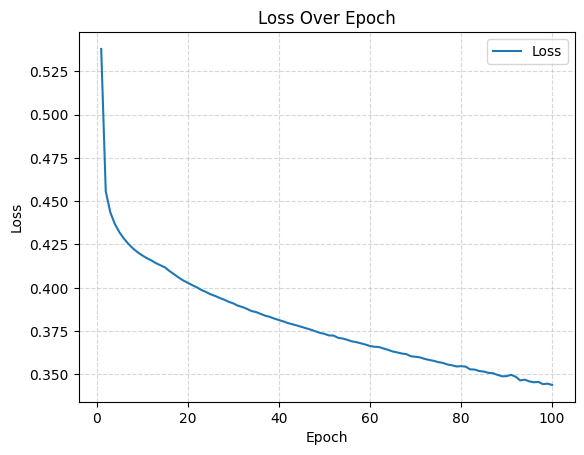

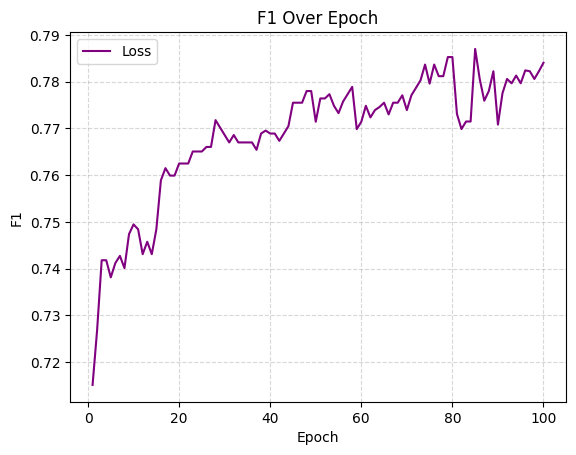

In [33]:
# Plot loss
epoch_elements = np.arange(1, epochs + 1)
plt.figure()
plt.plot(epoch_elements, losses, label = "Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epoch")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# Plot f1
epoch_elements = np.arange(1, epochs + 1)
plt.figure()
plt.plot(epoch_elements, f1_scores, label = "Loss", color="purple")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("F1 Over Epoch")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()